<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/read_wav_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Created by EDES**


mainly helped by claude-ai

Downloaded to local_wav_0.wav
Downloaded to local_wav_1.wav
Downloaded to local_wav_2.wav
Downloaded to local_wav_3.wav
Downloaded to local_wav_4.wav
Downloaded to local_wav_5.wav
Downloaded to local_wav_6.wav
data-0 length:165375 - rate:44100Hz - max_val:0.20678962767124176 @ 77143
data-1 length:165375 - rate:44100Hz - max_val:0.1265028566122055 @ 77155
data-2 length:165375 - rate:44100Hz - max_val:0.22090013325214386 @ 77140
data-3 length:165375 - rate:44100Hz - max_val:0.18920716643333435 @ 77175
data-4 length:165375 - rate:44100Hz - max_val:0.18075722455978394 @ 77141
data-5 length:165375 - rate:44100Hz - max_val:0.17937374114990234 @ 77138
data-6 length:165375 - rate:44100Hz - max_val:0.1833767294883728 @ 77175


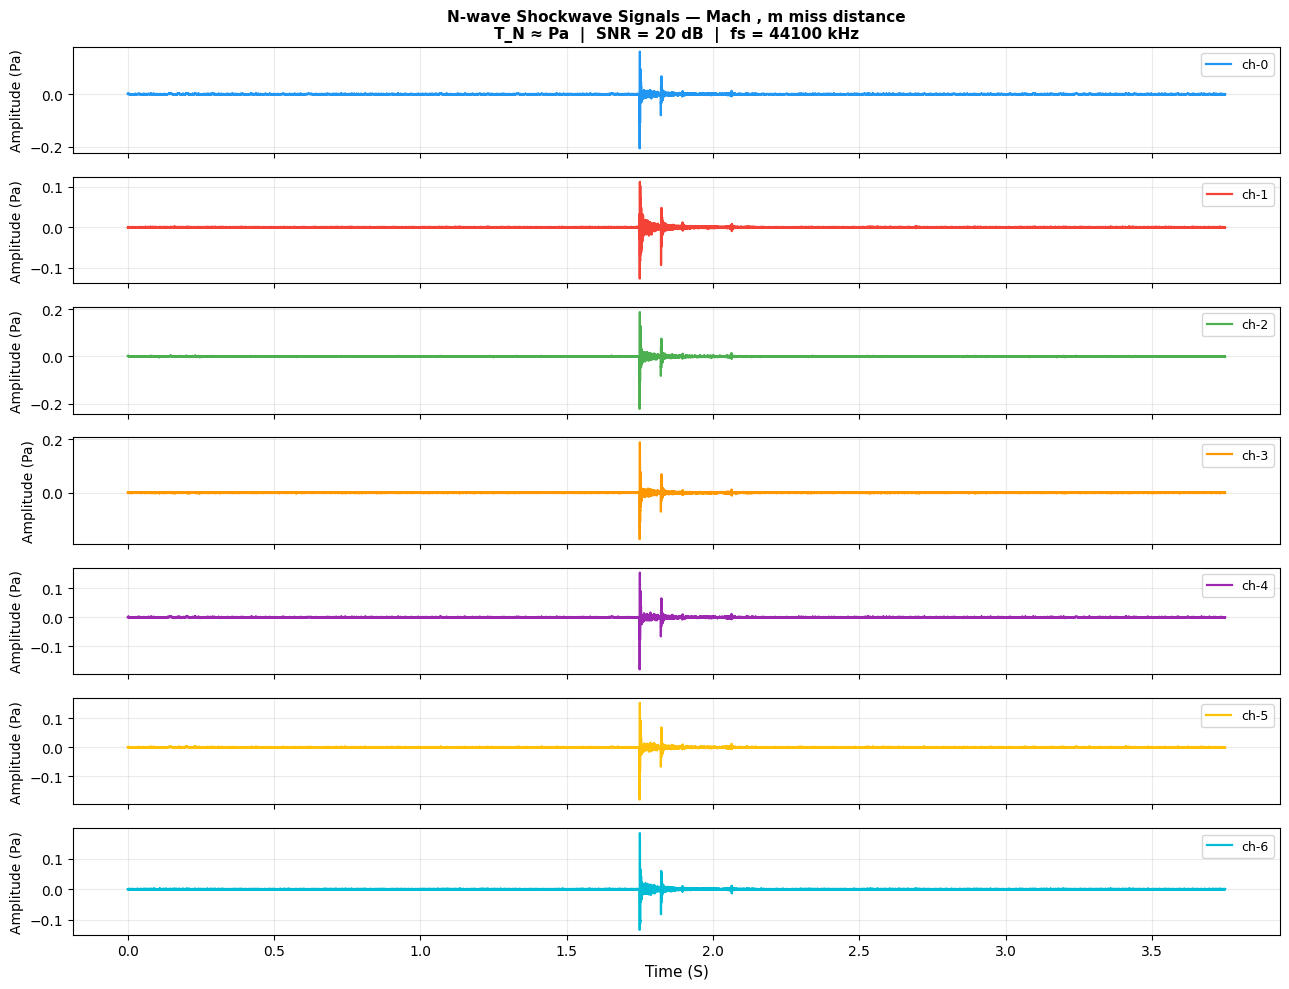

In [8]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

wav_file_url=[]
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch0.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch1.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch2.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch3.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch4.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch5.wav')
wav_file_url.append('https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/ruger_04_1s_ch6.wav')

num_files = len(wav_file_url)

local_file = []
for i in range(num_files):
  local_file.append(f'local_wav_{i}.wav')

# Check if the URL is provided
for i in range(num_files):
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url[i]}...")
        response = requests.get(wav_file_url[i])
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_file[i], 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_file[i]}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_file[i]}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

dataset_signal=[]; max_amplitude_val=[]; max_amplitude_idx=[]
for i in range(num_files):
  dataset_samplerate, dataset = wavfile.read(local_file[i])
  if dataset.ndim > 1:
    dataset = dataset[:, 0] # Take the first channel
  dataset_signal.append(dataset)
  max_amp_idx = np.argmax(np.abs(dataset))
  max_amp_val = np.max(np.abs(dataset))
  max_amplitude_idx.append(max_amp_idx)
  max_amplitude_val.append(max_amp_val)
  print(f"data-{i} length:{len(dataset)} - rate:{dataset_samplerate}Hz - max_val:{max_amp_val} @ {max_amp_idx}")

# Create a time array for the x-axis for the (possibly cropped) data
dataset_time = np.linspace(0., len(dataset) / dataset_samplerate, len(dataset))

COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#FFC107', '#00BCD4', '#8BC34A']

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — Mach , '
    f'm miss distance\n'
    f'T_N ≈ Pa  |  '
    f'SNR = 20 dB  |  fs = {dataset_samplerate} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

starting index for cropping:77015


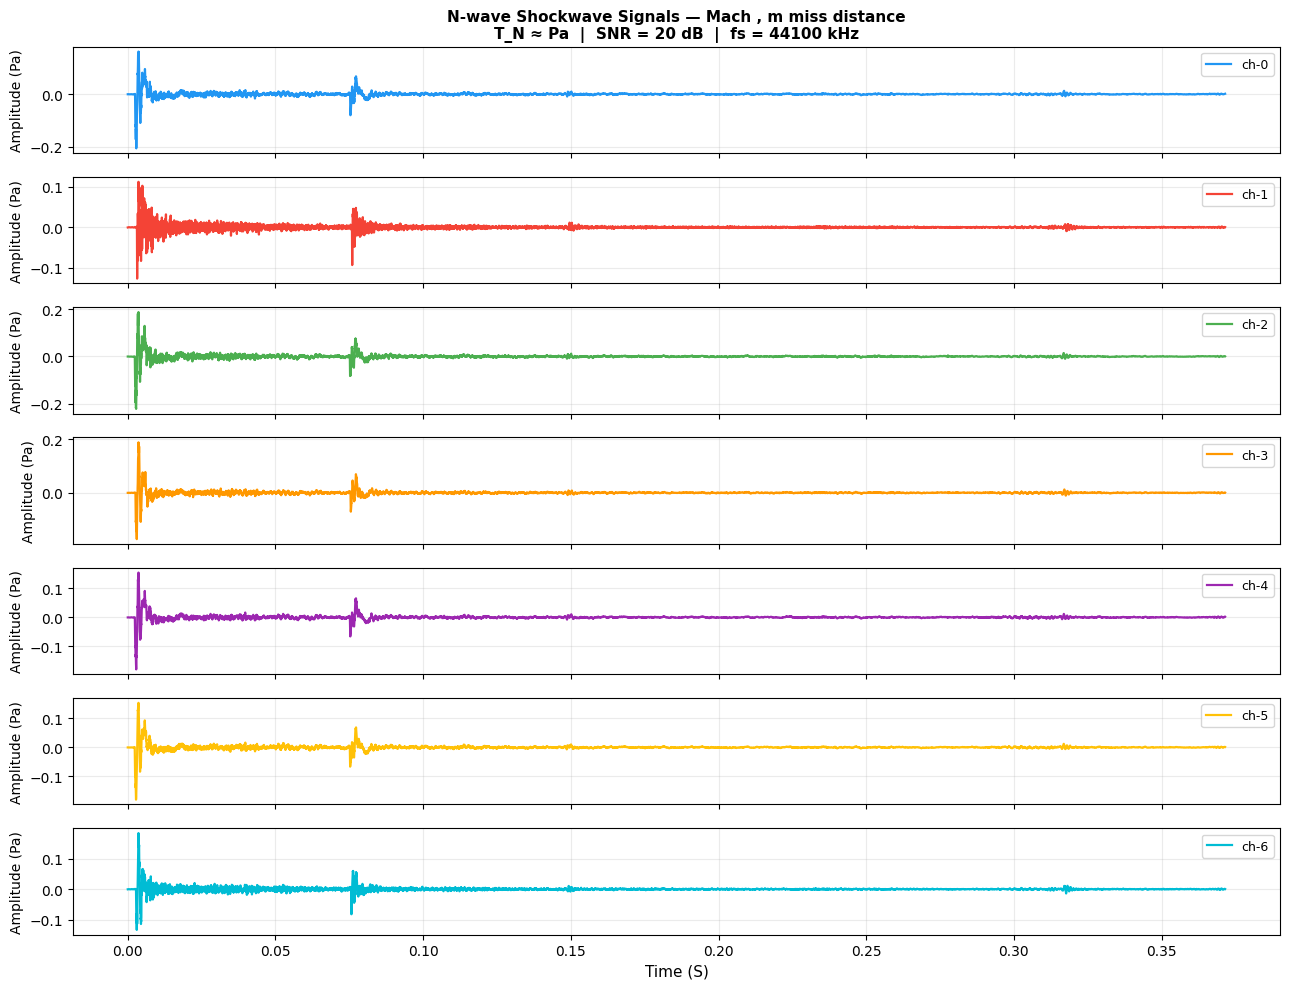

In [9]:
target_length = 2**14 # 16384 samples
smallest_offset = max(0, int(max_amplitude_idx[0] - 128))
print(f"starting index for cropping:{smallest_offset}")

for i in range(num_files):
  end_idx = smallest_offset + target_length
  dataset_signal[i] = dataset_signal[i][smallest_offset:end_idx]

dataset_time = np.linspace(0., target_length / dataset_samplerate, target_length)

fig, axes_s = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    ax = axes_s[i]
    ax.plot(dataset_time, dataset_signal[i], color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Amplitude (Pa)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

axes_s[-1].set_xlabel('Time (S)', fontsize=11)
axes_s[0].set_title(
    f'N-wave Shockwave Signals — fs = {dataset_samplerate} kHz',
    fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('nwave_signals.png', dpi=150, bbox_inches='tight')
plt.show()

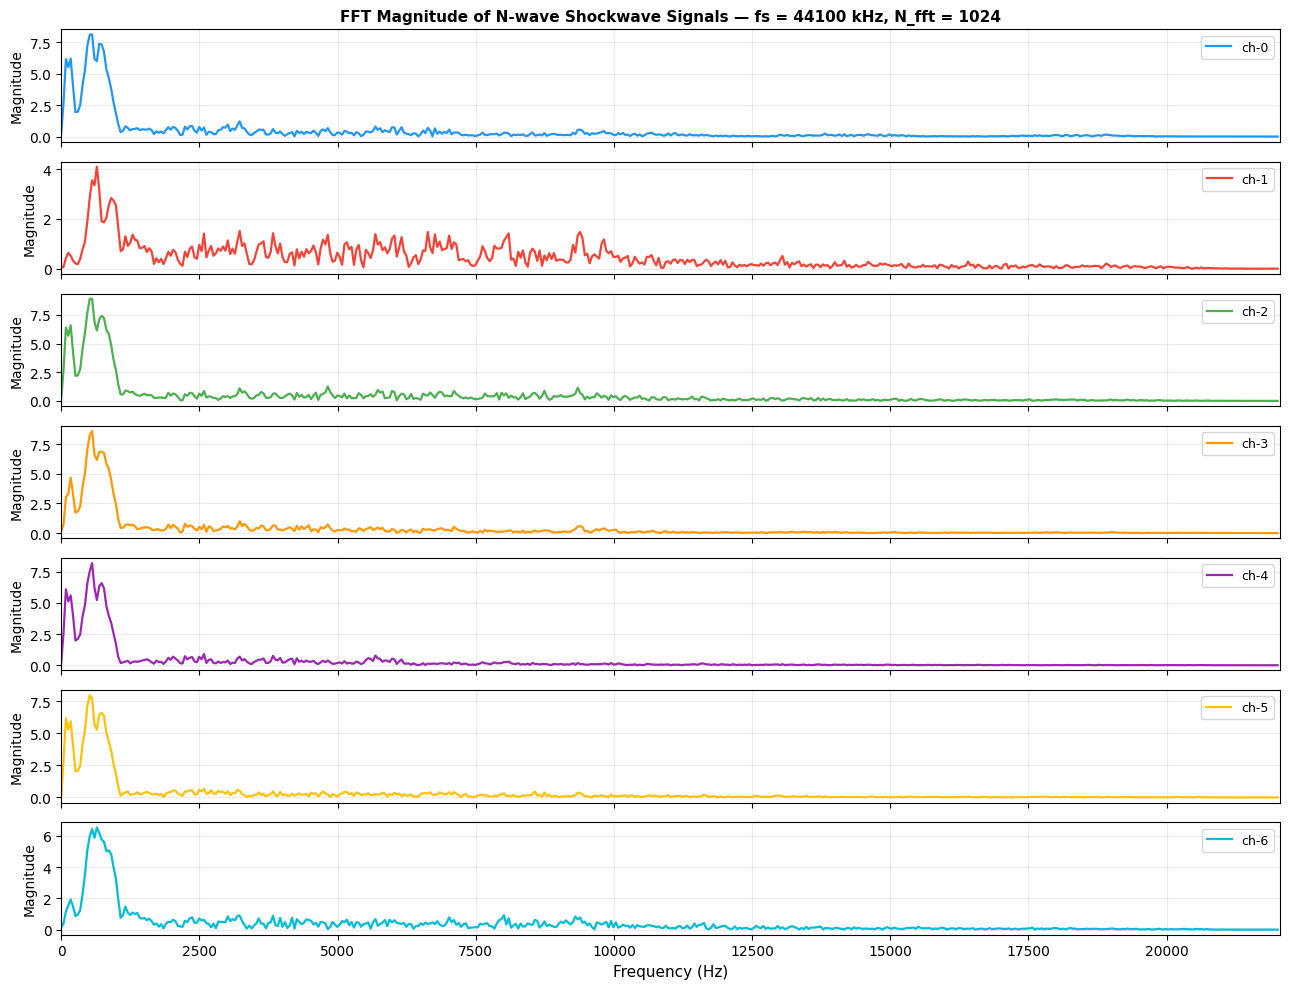

In [10]:
from scipy.fft import fft, fftfreq

# N_fft is already defined as 1024. For this FFT calculation, we will use N_fft.
# This means the FFT will be computed over 1024 samples. If the signal is longer
# than N_fft, it will effectively truncate or consider the first N_fft samples
# of the provided signal for the FFT, or it implies zero-padding if the signal is shorter.

N_fft = 1024 # Use the N_fft variable as the FFT length

# Calculate FFT and frequencies for each signal
freqs = fftfreq(N_fft, 1 / dataset_samplerate)

fig, axes_fft = plt.subplots(num_files, 1, figsize=(13, 10), sharex=True)
for i in range(num_files):
    # Compute FFT for the current signal using N_fft_actual points
    # If the signal length is greater than N_fft_actual, it will be truncated.
    yf = fft(dataset_signal[i], n=N_fft)
    # Take the magnitude and normalize, and consider only the positive frequencies
    magnitude = np.abs(yf[:N_fft // 2])

    ax = axes_fft[i]
    ax.plot(freqs[:N_fft // 2], magnitude, color=COLORS[i], lw=1.6, label=f'ch-{i}')
    ax.set_ylabel('Magnitude', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_xlim([0, dataset_samplerate / 2]) # Limit x-axis to Nyquist frequency

axes_fft[-1].set_xlabel('Frequency (Hz)', fontsize=11)
axes_fft[0].set_title(
    f'FFT Magnitude of N-wave Shockwave Signals — fs = {dataset_samplerate} kHz, N_fft = {N_fft}',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

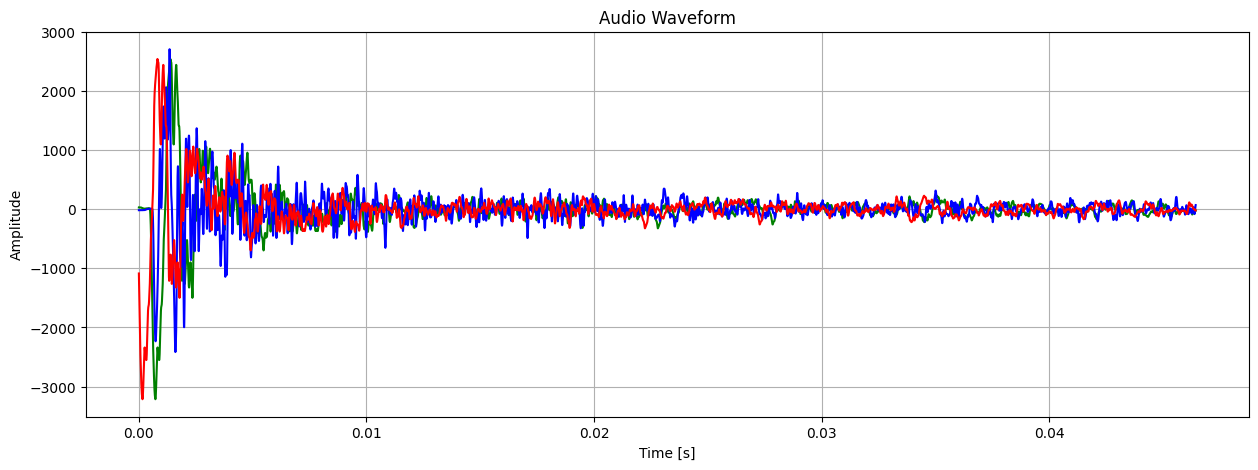

In [ ]:
from scipy.fft import fft, fftfreq

N_fft = 1024
delay_e = 100



# Find the index of the maximum amplitude in the cropped data
max_amplitude_index_1 = np.argmax(np.abs(data1))

# Get the maximum amplitude value
max_amplitude_value_1 = data1[max_amplitude_index_1]

# Create a cropped version of the audio data
cropped_start_index = int(max_amplitude_index_1 - (N_fft/8) )
cropped_end_index = int(cropped_start_index + N_fft * 8)
cropped_data1 = data1[cropped_start_index:cropped_end_index]
cropped_data2 = data2[cropped_start_index:cropped_end_index]
cropped_data3 = data1[cropped_start_index+delay_e:cropped_end_index+delay_e]
cropped_mixed_sine1 = mixed_sine[cropped_start_index:cropped_end_index]
cropped_mixed_sine2 = mixed_sine[cropped_start_index+delay_e:cropped_end_index+delay_e]

# Create a time array for the cropped data
cropped_time = np.linspace(0., len(cropped_data1) / samplerate, len(cropped_data1))

# Plot the waveform
plt.figure(figsize=(15, 5))
plt.plot(cropped_time, cropped_data1,'g')
plt.plot(cropped_time, cropped_data2,'b')
plt.plot(cropped_time, cropped_data3,'r')
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.grid(True)
plt.show()

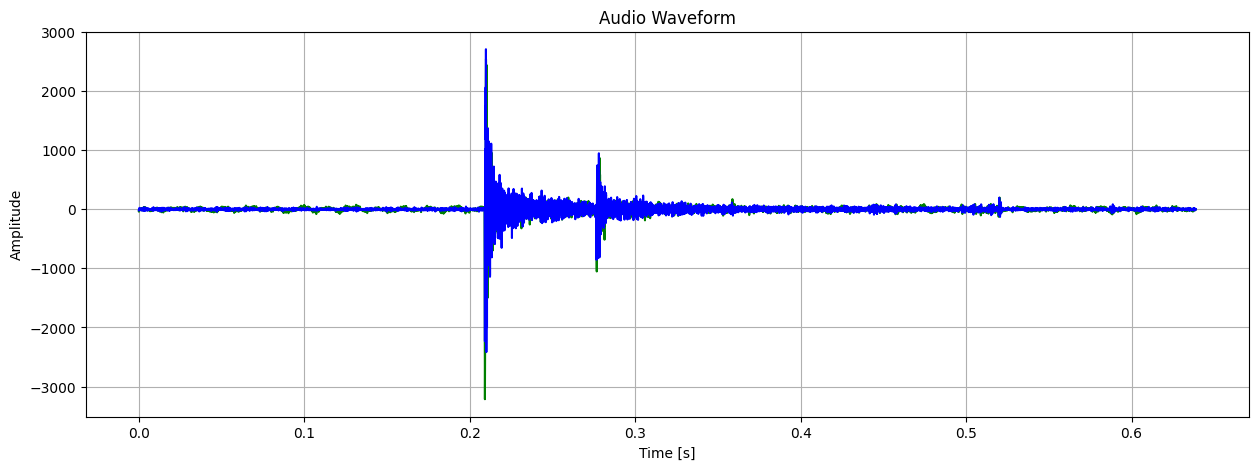

In [ ]:
# Read the WAV file


sine_50hz = np.sin(2 * np.pi * 50 * time1)
sine_120hz = 0.5 * np.sin(2 * np.pi * 120 * time1)
sine_320hz = 1.25 * np.sin(2 * np.pi * 320 * time1)
noise = 1.5 * np.random.normal(0, 0.5, len(sine_50hz))
mixed_sine = sine_50hz + sine_120hz + sine_320hz + noise

COLORS  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#FFC107', '#00BCD4', '#8BC34A']

# Plot the waveform
fig, axes_s = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for i in range(4):
    ax = axes_s[i]
    ax.plot(t_rel_ms[mask_w], signals[i][mask_w],
            color=COLORS[i], lw=1.6, label=f'M{i}')
    arr_rel = (t_arr[i] - t_ref) * 1e3
    ax.axvline(arr_rel, color=COLORS[i], ls='--', lw=1.4, alpha=0.9,
               label=f'Arrival: {arr_rel:+.4f} ms')
    ax.axhline(0,       color='black',    lw=0.5, alpha=0.35)
    ax.axhline( dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.axhline(-dPs[i], color=COLORS[i],  lw=0.6, ls=':', alpha=0.4)
    ax.set_ylabel('Pressure (Pa)', fontsize=10)
    ax.set_ylim([-dPs[i]*2.2, dPs[i]*2.2])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

plt.figure(figsize=(15, 5))
plt.plot(time1, data1,'g')
plt.plot(time2, data2,'b')
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.grid(True)
plt.show()

SciPy - Lag at maximum correlation: -1808 samples
SciPy - Time delay between signals: -0.010249 seconds


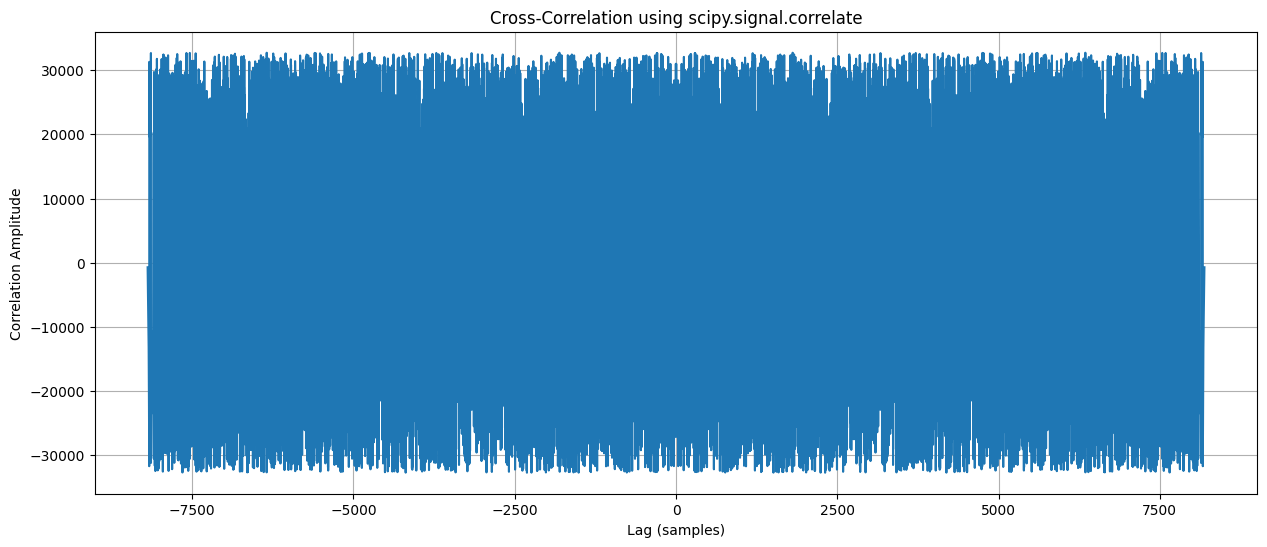

In [ ]:
from scipy import signal

# Compute cross-correlation using scipy.signal.correlate
# 'full' mode is equivalent to numpy.correlate's 'full' mode
#scipy_correlation = np.correlate(cropped_data1, cropped_data1, mode='full')
#scipy_correlation = signal.correlate(data1, data2, mode='full')
scipy_correlation = signal.correlate(cropped_data1, cropped_data1, mode='full')
#scipy_correlation = signal.fftconvolve(data1, data2, mode='full')
#scipy_correlation = signal.fftconvolve(cropped_mixed_sine1, cropped_mixed_sine1, mode='full')

# The lags array will be the same as calculated for numpy.correlate
# since the output length for 'full' mode is 2*N - 1, where N is the length of the shorter signal (data1/data2 here)
#lags_scipy = np.arange(-len(data1) + 1, len(data1))
#lags_scipy = np.arange(-len(cropped_data1) + 1, len(cropped_data1))
lags_scipy = signal.correlation_lags(len(cropped_data1), len(cropped_data1), mode='full')

# You can also verify that the results are very similar (or identical depending on data types and implementation details)
# print("Are numpy and scipy correlation results close?", np.allclose(correlation, scipy_correlation))

# Find the index of the maximum correlation from SciPy's result
max_scipy_correlation_index = np.argmax(scipy_correlation)
lag_at_max_scipy_correlation = lags_scipy[max_scipy_correlation_index]
time_delay_scipy = lag_at_max_scipy_correlation / samplerate

print(f"SciPy - Lag at maximum correlation: {lag_at_max_scipy_correlation} samples")
print(f"SciPy - Time delay between signals: {time_delay_scipy:.6f} seconds")

# Plot the cross-correlation from SciPy
plt.figure(figsize=(15, 6))
plt.plot(lags_scipy, scipy_correlation)
plt.title('Cross-Correlation using scipy.signal.correlate')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation Amplitude')
plt.grid(True)
plt.show()